In [2]:
import torch
print(f"Is GPU available? {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Is GPU available? True
GPU Name: NVIDIA RTX 2000 Ada Generation


In [5]:
pip install pandas

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 11.3/11.3 MB 59.0 MB/s  0:00:00

   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]


In [3]:
import pandas as pd

# Load datasets
trades = pd.read_csv(r"C:\Users\Tihan_05\Desktop\Siva\Assign_inter\historical_data.csv")
sentiment = pd.read_csv(r"C:\Users\Tihan_05\Desktop\Siva\Assign_inter\fear_greed_index.csv")

# Preview
print(trades.head())
print(sentiment.head())

# Check columns
print(trades.columns)
print(sentiment.columns)

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [5]:
# Convert timestamps correctly
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

sentiment['date'] = pd.to_datetime(sentiment['date'])

# Create common date column
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [6]:
print(trades.isnull().sum())
print(sentiment.isnull().sum())

# Fill or drop
trades = trades.dropna()
sentiment = sentiment.dropna()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [7]:
merged = pd.merge(trades, sentiment, on='date', how='inner')

print(merged.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [8]:
merged['Closed PnL'] = pd.to_numeric(merged['Closed PnL'], errors='coerce')

In [9]:
merged['Side'] = merged['Side'].astype(str)

In [10]:
profit_by_sentiment = merged.groupby('classification')['Closed PnL'].mean()
print(profit_by_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [11]:
count_by_sentiment = merged['classification'].value_counts()
print(count_by_sentiment)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [12]:
buy_sell = pd.crosstab(merged['classification'], merged['Side'])
print(buy_sell)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


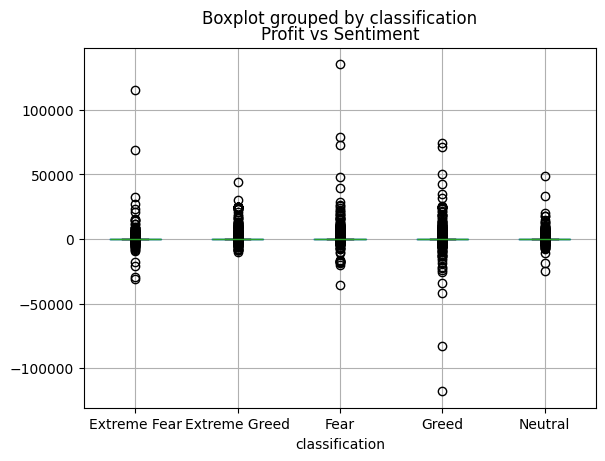

In [13]:
import matplotlib.pyplot as plt

merged.boxplot(column='Closed PnL', by='classification')
plt.title("Profit vs Sentiment")
plt.show()

In [14]:
merged['value'] = pd.to_numeric(merged['value'], errors='coerce')

correlation = merged[['Closed PnL', 'value']].corr()
print(correlation)

            Closed PnL     value
Closed PnL    1.000000  0.008121
value         0.008121  1.000000


In [15]:
merged.groupby('classification')['Closed PnL'].sum().sort_values(ascending=False)

classification
Fear             3.357155e+06
Extreme Greed    2.715171e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Extreme Fear     7.391102e+05
Name: Closed PnL, dtype: float64

In [16]:
top_traders = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False)
print(top_traders.head())


Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
Name: Closed PnL, dtype: float64


In [28]:
from sklearn.linear_model import LinearRegression

X = merged[['value']]  # sentiment score
y = merged['Closed PnL']

model = LinearRegression()
model.fit(X, y)

print(model.coef_)

[0.35476255]


In [27]:
pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 8.9/8.9 MB 55.3 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3

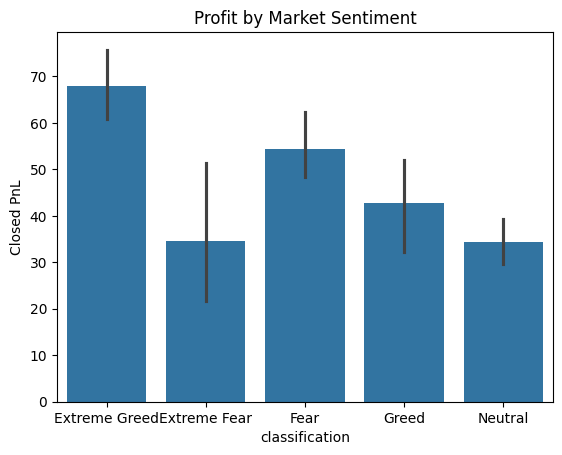

In [31]:
import seaborn as sns

sns.barplot(x='classification', y='Closed PnL', data=merged)
plt.title("Profit by Market Sentiment")
plt.show()

In [30]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.
